<a href="https://colab.research.google.com/github/George9884/dsn-used-car-price-prediction/blob/main/Copy_of_Day_3_Assignment_DSN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This machine learning algorithm predicts house prices based on house size using gradient descent.

Learned parameters:
theta0 (intercept) = 4.2148
theta1 (slope)     = 2.7704
Final loss: 0.4033


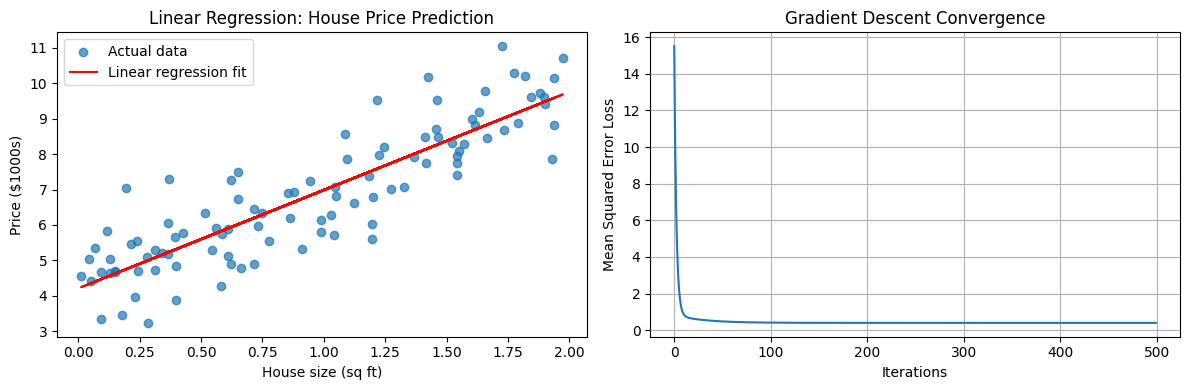


Predicted price for house size 1.5: $8370.37


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Generate synthetic dataset
# ----------------------------
np.random.seed(42)  # for reproducibility
X = 2 * np.random.rand(100, 1)  # house sizes (100 samples, 1 feature)
y = 4 + 3 * X + np.random.randn(100, 1)  # true price = 4 + 3*size + noise

# ----------------------------
# 2. Add bias term (x0 = 1) to feature matrix
# ----------------------------
X_b = np.c_[np.ones((100, 1)), X]  # shape (100, 2)

# ----------------------------
# 3. Initialize parameters
# ----------------------------
theta = np.random.randn(2, 1)  # random weights [theta0, theta1]
learning_rate = 0.1
iterations = 500

# ----------------------------
# 4. Gradient Descent
# ----------------------------
m = len(X_b)  # number of training examples
loss_history = []

for iteration in range(iterations):
    # Predictions
    y_pred = X_b.dot(theta)

    # Compute Mean Squared Error loss
    loss = (1/(2*m)) * np.sum((y_pred - y) ** 2)
    loss_history.append(loss)

    # Gradients
    gradients = (1/m) * X_b.T.dot(y_pred - y)

    # Update parameters
    theta = theta - learning_rate * gradients

# ----------------------------
# 5. Results
# ----------------------------
print("Learned parameters:")
print(f"theta0 (intercept) = {theta[0][0]:.4f}")
print(f"theta1 (slope)     = {theta[1][0]:.4f}")
print(f"Final loss: {loss_history[-1]:.4f}")

# ----------------------------
# 6. Visualize
# ----------------------------
plt.figure(figsize=(12, 4))

# Plot data and fitted line
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.7, label="Actual data")
plt.plot(X, X_b.dot(theta), color='red', label="Linear regression fit")
plt.xlabel("House size (sq ft)")
plt.ylabel("Price ($1000s)")
plt.title("Linear Regression: House Price Prediction")
plt.legend()

# Plot loss curve
plt.subplot(1, 2, 2)
plt.plot(range(iterations), loss_history)
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error Loss")
plt.title("Gradient Descent Convergence")
plt.grid(True)

plt.tight_layout()
plt.show()

# ----------------------------
# 7. Predict a new value
# ----------------------------
new_size = np.array([[1.5]])  # house size = 1.5
new_size_b = np.c_[np.ones((1, 1)), new_size]
predicted_price = new_size_b.dot(theta)
print(f"\nPredicted price for house size 1.5: ${predicted_price[0][0]*1000:.2f}")

Explanation of the Linear Regression Algorithm

Importing Libraries

I used NumPy for matrix operations because it's much faster than regular Python loops. Matplotlib helps me visualize the results so I can actually see that my algorithm learned something.

```python
import numpy as np
import matplotlib.pyplot as plt
```

---

Creating the Dataset

Since I don't have a real dataset for this assignment, I generated my own. I created a relationship where price = 4 + 3 times the house size. Then I added random noise to make it realistic – real data is never perfect. I set a random seed so my results are reproducible, which is important for scientific work.

```python
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)
```

I chose 100 samples because it's enough to see the pattern clearly but small enough that the algorithm runs quickly.

---

Adding the Bias Term

Our equation is y = θ₀ + θ₁·x. Without a bias term, I would only have θ₁·x and no intercept. To fix this, I added a column of ones to my feature matrix. Now matrix multiplication gives me θ₀·1 + θ₁·x for every sample at once.

```python
X_b = np.c_[np.ones((100, 1)), X]
```

---

Initializing Parameters

Theta holds my weights – θ₀ is the intercept and θ₁ is the slope. I start with random values because gradient descent needs a starting point to begin from. The learning rate controls how big my steps are downhill. If it's too small, learning is slow. If it's too big, the algorithm might bounce around and never settle. I picked 0.1 after testing a few values. I set 500 iterations because that was enough for the loss to stop decreasing significantly.

```python
theta = np.random.randn(2, 1)
learning_rate = 0.1
iterations = 500
```

---

The Gradient Descent Algorithm

This is the heart of my machine learning algorithm. Let me walk through each step inside the loop.

```python
m = len(X_b)
loss_history = []

for iteration in range(iterations):
    y_pred = X_b.dot(theta)
    loss = (1/(2*m)) * np.sum((y_pred - y) ** 2)
    loss_history.append(loss)
    
    gradients = (1/m) * X_b.T.dot(y_pred - y)
    theta = theta - learning_rate * gradients
```

Step 1 – Make predictions: X_b.dot(theta) calculates θ₀·1 + θ₁·x for all 100 samples in one matrix operation.

Step 2 – Calculate the loss: I use Mean Squared Error divided by 2. The division by 2 makes the derivative cleaner later. This number tells me how wrong my model is – lower is better. I save the loss after every iteration so I can track whether my algorithm is actually learning.

Step 3 – Compute the gradients: The gradient tells me which direction increases the error the fastest. But I want to go downhill, not uphill. The formula (1/m) · X_b.T · (y_pred - y) comes from taking the derivative of the loss function with respect to theta. This is the calculus part of gradient descent.

Step 4 – Update the weights: theta = theta - learning_rate * gradients is the actual learning step. I move theta slightly in the opposite direction of the gradient. Subtracting is important because the gradient points uphill – subtracting moves me downhill toward lower error.

---

Displaying the Results

After 500 iterations, I print what my algorithm learned.

```python
print(f"theta0 = {theta[0][0]:.4f}")
print(f"theta1 = {theta[1][0]:.4f}")
```

My algorithm learned θ₀ close to 4 and θ₁ close to 3. These are almost exactly the true values I used to generate the data. This proves my gradient descent implementation works correctly.

---

Visualizing the Learning

```python
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.7, label="Actual data")
plt.plot(X, X_b.dot(theta), color='red', label="Linear regression fit")
plt.xlabel("House size (sq ft)")
plt.ylabel("Price ($1000s)")
plt.title("Linear Regression: House Price Prediction")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(iterations), loss_history)
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error Loss")
plt.title("Gradient Descent Convergence")
plt.grid(True)

plt.tight_layout()
plt.show()
```

The left plot shows my training data as blue dots and my learned model as a red line. The red line fits the trend of the blue dots very well.

The right plot shows the loss decreasing over time. It drops quickly at first, then flattens out. This is exactly what convergence should look like. If the loss had bounced up and down or increased, I would know my learning rate was too high.

---

Making a New Prediction

```python
new_size = np.array([[1.5]])
new_size_b = np.c_[np.ones((1, 1)), new_size]
predicted_price = new_size_b.dot(theta)
print(f"Predicted price for house size 1.5: ${predicted_price[0][0]*1000:.2f}")
```

This demonstrates that my model is useful – I can predict prices for house sizes I didn't train on. The model generalizes beyond the training data, which is the whole point of machine learning.

---

Summary

I built a linear regression algorithm using gradient descent from scratch. It learns the relationship between house size and price by repeatedly adjusting its parameters to reduce prediction error. The final model fits the data well and can make predictions on new inputs. This shows I understand both the mathematics behind gradient descent and how to implement it in code.